# TextGrad Optimization & Ablation Study

Visualizes:
1. **TextGrad training** — metrics per step, prompt evolution, convergence
2. **Ablation study** — all four conditions compared head-to-head

Re-run cells top-to-bottom after any new training or evaluation run.

In [47]:
import json
import difflib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 130
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

PROJECT_ROOT = Path("..").resolve()
TG_DIR       = PROJECT_ROOT / "results" / "textgrad_validation"
ABL_DIR      = PROJECT_ROOT / "results" / "ablation"

print(f"TextGrad results : {TG_DIR}")
print(f"Ablation results : {ABL_DIR}")


TextGrad results : /Users/louisewiljander/Documents/Projects/llm-vc-decision-textgrad/llm-vc-decision-textgrad/results/textgrad_validation
Ablation results : /Users/louisewiljander/Documents/Projects/llm-vc-decision-textgrad/llm-vc-decision-textgrad/results/ablation


## 1. Load TextGrad training results

In [48]:
def load_metrics():
    path = TG_DIR / "metrics_per_step.jsonl"
    rows = []
    if path.exists():
        for line in path.read_text().splitlines():
            if line.strip():
                rec = json.loads(line)
                flat = {**rec, **rec.pop('val_metrics', {})}
                rows.append(flat)
    return rows

def load_prompts():
    prompts = {}
    if TG_DIR.exists():
        for f in sorted(TG_DIR.glob("prompt_step_*.txt")):
            step = int(f.stem.split("_")[-1])
            prompts[step] = f.read_text()
    return prompts

def load_final():
    out = {}
    p = TG_DIR / "final_metrics.json"
    if p.exists():
        out['metrics'] = json.loads(p.read_text())
    p = TG_DIR / "final_synthesizer_prompt.txt"
    if p.exists():
        out['prompt'] = p.read_text()
    p = TG_DIR / "data_splits.json"
    if p.exists():
        out['splits'] = json.loads(p.read_text())
    return out

metrics_data = load_metrics()
prompts      = load_prompts()
final        = load_final()

print(f"Training steps loaded : {len(metrics_data)}")
print(f"Prompt snapshots      : {len(prompts)}")
if 'splits' in final:
    s = final['splits']
    print(f"Train / val sizes     : {s.get('n_train')} / {s.get('n_val')}")


Training steps loaded : 1
Prompt snapshots      : 5
Train / val sizes     : 5 / 10


## 2. Metrics evolution across training steps

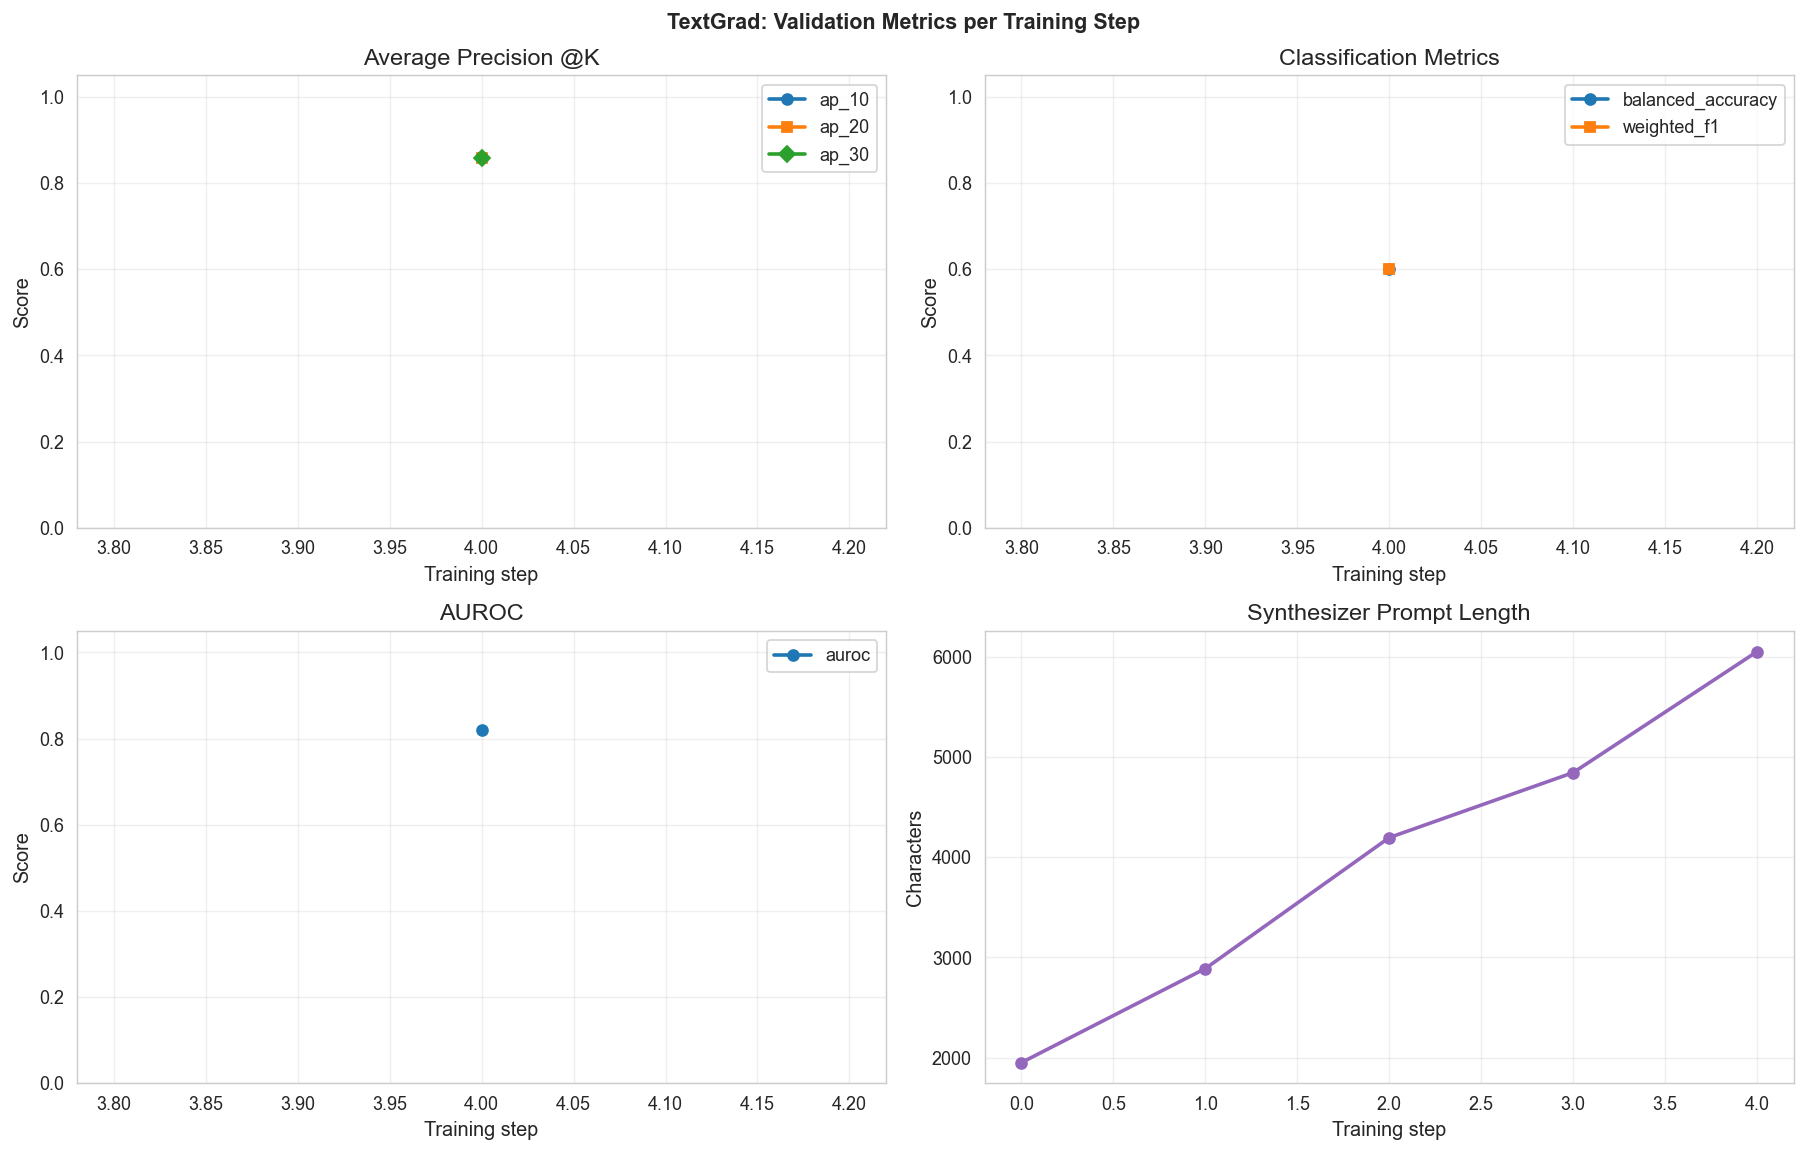

,step,auroc,balanced_accuracy,weighted_f1,ap_10,ap_20,ap_30
0,4,0.82,0.6,0.6,0.8583,0.8583,0.8583


In [49]:
if metrics_data:
    df = pd.DataFrame(metrics_data)
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    fig.suptitle("TextGrad: Validation Metrics per Training Step", fontweight='bold')

    def plot(ax, cols, title, ylabel='Score'):
        for col, marker in zip(cols, 'osDv'):
            if col in df.columns:
                ax.plot(df['step'] if 'step' in df.columns else df.index,
                        df[col], marker=marker, label=col, linewidth=2)
        ax.set_xlabel('Training step'); ax.set_ylabel(ylabel)
        ax.set_title(title); ax.legend(); ax.set_ylim(0, 1.05); ax.grid(alpha=0.3)

    plot(axes[0,0], ['ap_10','ap_20','ap_30'],       'Average Precision @K')
    plot(axes[0,1], ['balanced_accuracy','weighted_f1'], 'Classification Metrics')
    plot(axes[1,0], ['auroc'],                        'AUROC')

    # Prompt length over steps
    if prompts:
        steps  = sorted(prompts.keys())
        lengths= [len(prompts[s]) for s in steps]
        axes[1,1].plot(steps, lengths, marker='o', color='tab:purple', linewidth=2)
        axes[1,1].set_xlabel('Training step')
        axes[1,1].set_ylabel('Characters')
        axes[1,1].set_title('Synthesizer Prompt Length')
        axes[1,1].grid(alpha=0.3)

    plt.tight_layout(); plt.show()

    # Summary table
    display(df[['step','auroc','balanced_accuracy','weighted_f1','ap_10','ap_20','ap_30']].round(4))
else:
    print("⚠️  No metrics found. Run: python experiments/run_textgrad.py --n_train 5 --n_val 5")


## 3. Convergence analysis

In [55]:
if metrics_data and len(metrics_data) >= 3:
    df = pd.DataFrame(metrics_data)
    for metric in ['balanced_accuracy', 'auroc', 'weighted_f1']:
        if metric not in df.columns:
            continue
        vals = df[metric].values
        delta_total = vals[-1] - vals[0]
        delta_last3 = vals[-1] - vals[-3]
        converged   = abs(delta_last3) < 0.01
        print(f"{metric:<22}  start={vals[0]:.4f}  end={vals[-1]:.4f}  "
              f"Δtotal={delta_total:+.4f}  Δlast3={delta_last3:+.4f}  "
              f"{'✓ converged' if converged else '⚠ still moving'}")
else:
    print("Need ≥3 steps to assess convergence.")


Need ≥3 steps to assess convergence.


## 4. Prompt evolution

In [51]:
if len(prompts) >= 2:
    steps = sorted(prompts.keys())
    print(f"Steps: {steps}")
    print(f"Initial length : {len(prompts[steps[0]])} chars")
    print(f"Final length   : {len(prompts[steps[-1]])} chars\n")

    for i in range(len(steps) - 1):
        a, b = prompts[steps[i]], prompts[steps[i+1]]
        diff = list(difflib.unified_diff(a.splitlines(), b.splitlines(), lineterm=''))
        adds = sum(1 for l in diff if l.startswith('+') and not l.startswith('+++'))
        dels = sum(1 for l in diff if l.startswith('-') and not l.startswith('---'))
        changes = [l for l in diff if l.startswith(('+','-'))
                   and not l.startswith(('+++','---'))]
        print(f"Step {steps[i]} → {steps[i+1]}:  +{adds} lines  -{dels} lines")
        for c in changes[:3]:
            sym = '➕' if c[0] == '+' else '➖'
            print(f"   {sym} {c[1:80]}")
        print()
else:
    print("No prompt snapshots found yet.")


Steps: [0, 1, 2, 3, 4]
Initial length : 1950 chars
Final length   : 6055 chars

Step 0 → 1:  +11 lines  -1 lines
   ➖ After producing the JSON output, critically analyze the input analyst reports a
   ➕ **Decision Prioritization and Conflict Resolution:**
   ➕ *   **Prioritize Positive Signals:** Actively seek and weigh factors that suppo

Step 1 → 2:  +4 lines  -3 lines
   ➖ Stay critical. Most startups will not succeed — your task is to identify the ra
   ➕ Stay critical. Most startups will not succeed — your task is to identify the ra
   ➖ *   **Weighted Confidence:** Calculate a weighted score where 'PROMISING' decis

Step 2 → 3:  +9 lines  -3 lines
   ➕ **Probability Calibration:**
   ➕ *   Calculate a base probability for a startup in this sector (assume a general
   ➕ *   Increase probability for strong positive signals (high confidence, unique d

Step 3 → 4:  +33 lines  -10 lines
   ➕ **Quantification of Red Flags:**
   ➕ Please quantify the significance of each red flag mentio

## 5. Initial vs. final prompt (full diff)

In [52]:
if len(prompts) >= 2:
    steps = sorted(prompts.keys())
    initial, final_p = prompts[steps[0]], prompts[steps[-1]]
    diff = difflib.unified_diff(
        initial.splitlines(keepends=True),
        final_p.splitlines(keepends=True),
        fromfile=f'step_{steps[0]}',
        tofile=f'step_{steps[-1]}',
    )
    print(''.join(diff))
else:
    print("Need at least 2 prompt snapshots.")


--- step_0
+++ step_4
@@ -1,6 +1,6 @@
 You are the chief analyst at a venture capital firm. You receive evaluation reports from four independent specialist analysts and must synthesize their perspectives into a single investment recommendation.
 
-Stay critical. Most startups will not succeed — your task is to identify the rare exceptions.
+Stay critical. Most startups will not succeed — your task is to identify the rare exceptions. Employ a critical lens, actively seeking and rigorously evaluating potential flaws or unmitigated risks. Your default inclination should be skepticism; only an 'INVEST' decision should result from a compelling, evidence-backed case that overcomes significant potential downsides.
 
 ANALYSTS:
 1. Market Analyst (sector, geography, market timing)
@@ -11,17 +11,57 @@
 YOUR TASK:
 Weigh the four analyst reports and produce a single binary INVEST/PASS decision with a calibrated probability of successful exit.
 
-After producing the JSON output, critically analyz

## 6. Ablation study: all four conditions

In [56]:
def load_ablation_metrics(prefix: str) -> dict | None:
    """Load the most recent metrics file matching `prefix`.
    Falls back to archived results if no current results exist."""    
    # Try current results directory first
    files = sorted(ABL_DIR.glob(f"{prefix}*_metrics.json"))
    
    # If not found, check archive subdirectories (most recent first)
    if not files:
        archive_dir = ABL_DIR / "archive"
        if archive_dir.exists():
            for archive_subdir in sorted(archive_dir.iterdir(), reverse=True):
                if archive_subdir.is_dir():
                    files = sorted(archive_subdir.glob(f"{prefix}*_metrics.json"))
                    if files:
                        break
    
    if not files:
        return None
    
    with open(files[-1]) as f:
        return json.load(f)

conditions = {
    'Random':   load_ablation_metrics('random_'),
    'Single':   load_ablation_metrics('single_'),
    'Multi':    load_ablation_metrics('multi_'),
    'TextGrad': load_ablation_metrics('textgrad_'),
}

for name, m in conditions.items():
    status = f"n={m.get('n', m.get('n_evaluated','?'))}  AUROC={m.get('auroc',float('nan')):.3f}" if m else "not found"
    print(f"  {name:<10} {status}")

  Random     n=20  AUROC=0.495
  Single     n=20  AUROC=0.783
  Multi      n=20  AUROC=0.758
  TextGrad   n=20  AUROC=0.717


,auroc,balanced_accuracy,weighted_f1,ap_10,ap_20,ap_30
Condition,,,,,,
Random,0.4949,0.5051,0.5000,0.2963,0.5756,0.5756
Single,0.7828,0.7525,0.7619,0.6125,0.7507,0.7507
Multi,0.7576,0.7323,0.8000,0.5309,0.6693,0.6693
TextGrad,0.7172,0.6616,0.6316,0.3898,0.6412,0.6412


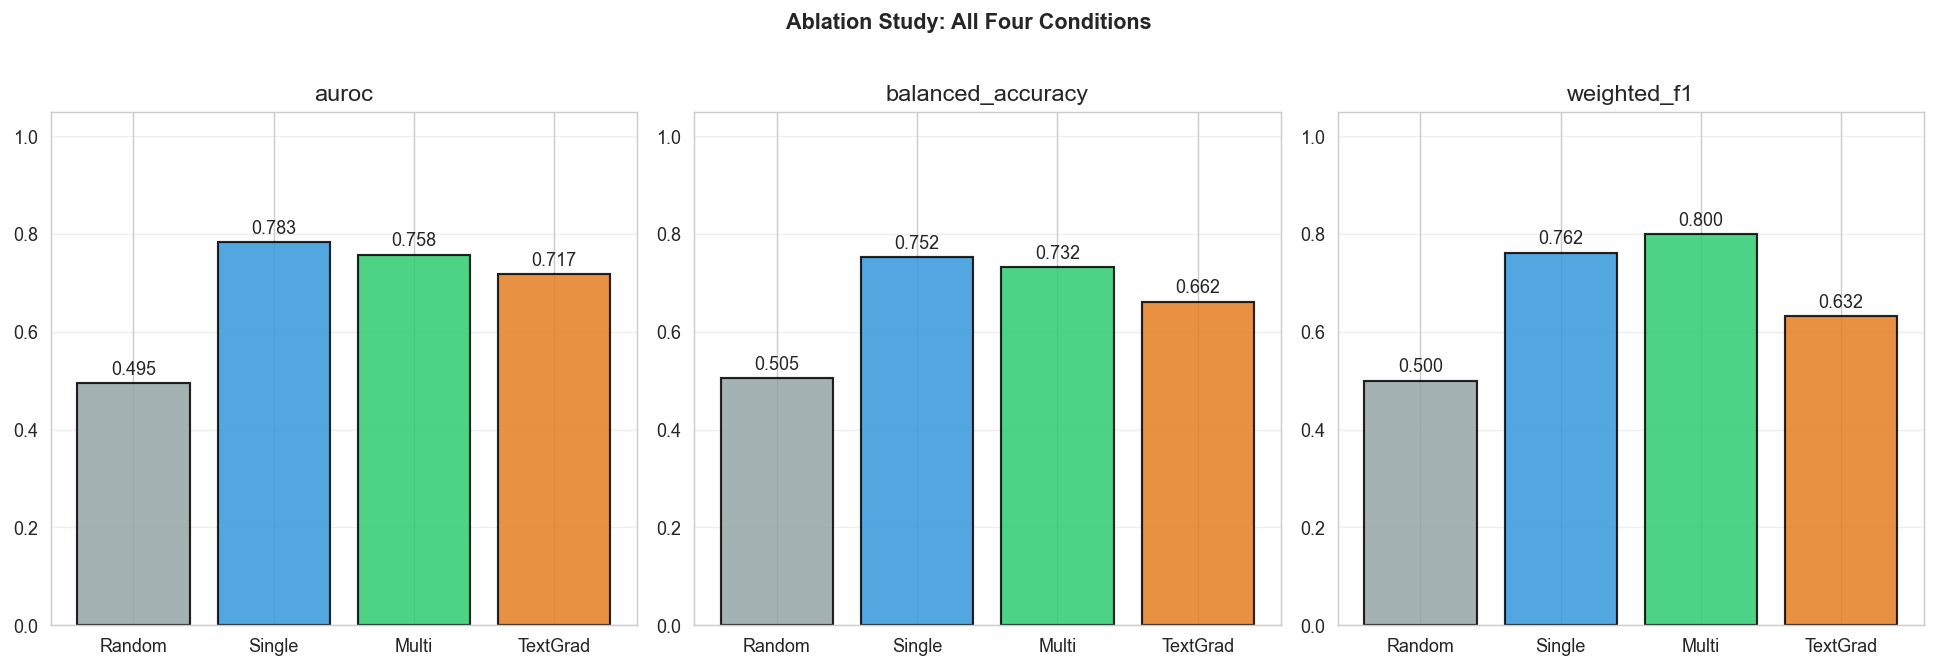

In [57]:
available = {k: v for k, v in conditions.items() if v is not None}

if available:
    metrics_to_show = ['auroc', 'balanced_accuracy', 'weighted_f1', 'ap_10', 'ap_20', 'ap_30']
    rows = []
    for name, m in available.items():
        row = {'Condition': name}
        # handle both 'f1' and 'weighted_f1' key names
        if 'weighted_f1' not in m and 'f1' in m:
            m['weighted_f1'] = m['f1']
        for met in metrics_to_show:
            row[met] = m.get(met, float('nan'))
        rows.append(row)

    cmp = pd.DataFrame(rows).set_index('Condition')
    display(cmp.round(4))

    # Bar charts
    plot_metrics = [m for m in ['auroc','balanced_accuracy','weighted_f1'] if m in cmp.columns]
    fig, axes = plt.subplots(1, len(plot_metrics), figsize=(5*len(plot_metrics), 5))
    if len(plot_metrics) == 1: axes = [axes]

    palette = {'Random':'#95a5a6','Single':'#3498db','Multi':'#2ecc71','TextGrad':'#e67e22'}
    for ax, met in zip(axes, plot_metrics):
        vals = cmp[met]
        colors = [palette.get(c, 'steelblue') for c in vals.index]
        bars = ax.bar(vals.index, vals.values, color=colors, alpha=0.85, edgecolor='black', linewidth=1.2)
        ax.set_ylim(0, 1.05)
        ax.set_title(met)
        ax.grid(axis='y', alpha=0.3)
        for bar in bars:
            h = bar.get_height()
            if not np.isnan(h):
                ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.3f}',
                        ha='center', va='bottom', fontsize=10)

    plt.suptitle("Ablation Study: All Four Conditions", fontweight='bold', y=1.02)
    plt.tight_layout(); plt.show()
else:
    print("No ablation results found yet.")
    print("Run:  python experiments/run_experiments.py")


## 7. LLM-as-judge: reasoning quality across conditions

Post-hoc evaluation scoring reasoning quality on 6 dimensions (Schumpeter's innovation theory + VC criteria) across single agent, multi-analyst, and TextGrad conditions. Run `python experiments/run_judge_evaluation.py` to generate results.

In [1]:
from pathlib import Path
PROJECT_ROOT = Path("..").resolve()
JUDGE_DIR = PROJECT_ROOT / "results" / "judge_evaluation"

def load_latest_judge_scores() -> pd.DataFrame | None:
    files = sorted(JUDGE_DIR.glob("judge_scores_*.jsonl"), key=lambda p: p.stat().st_mtime)
    if not files:
        return None
    rows = []
    with open(files[-1]) as f:
        for line in f:
            if line.strip():
                rows.append(json.loads(line))
    df = pd.DataFrame(rows)
    print(f"Loaded {len(df)} records from {files[-1].name}")
    return df

def load_latest_judge_summary() -> pd.DataFrame | None:
    files = sorted(JUDGE_DIR.glob("judge_summary_*.json"), key=lambda p: p.stat().st_mtime)
    if not files:
        return None
    return pd.read_json(files[-1])

judge_df   = load_latest_judge_scores()
judge_smry = load_latest_judge_summary()


NameError: name 'PROJECT_ROOT' is not defined

In [ ]:
if judge_smry is not None:
    dims = ['product novelty','market opportunity','feasibility',
            'team quality','reasoning coherence','risk identification']
    available_dims = [d for d in dims if d in judge_smry.columns]
    
    print("Average scores by condition (1–5 scale):\n")
    display(judge_smry[available_dims + ['total_score']].round(2) if 'total_score' in judge_smry.columns
            else judge_smry[available_dims].round(2))

    # Radar / bar comparison
    order = [c for c in ['single','multi','textgrad'] if c in judge_smry.index]
    palette = {'single':'#3498db','multi':'#2ecc71','textgrad':'#e67e22'}

    fig, ax = plt.subplots(figsize=(12, 5))
    x = np.arange(len(available_dims))
    width = 0.25
    for i, cond in enumerate(order):
        if cond not in judge_smry.index:
            continue
        vals = [judge_smry.loc[cond, d] if d in judge_smry.columns else 0 for d in available_dims]
        bars = ax.bar(x + i*width, vals, width, label=cond.capitalize(),
                      color=palette.get(cond,'grey'), alpha=0.85, edgecolor='black', linewidth=1.1)
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.04, f'{h:.1f}',
                    ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x + width)
    ax.set_xticklabels([d.replace(' ', '\n') for d in available_dims], fontsize=9)
    ax.set_ylim(0, 5.8)
    ax.set_ylabel('Average score (1–5)')
    ax.set_title('LLM-as-judge: Reasoning Quality by Condition and Dimension', fontweight='bold')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No judge results found. Run: python experiments/run_judge_evaluation.py --n_sample 10")


In [ ]:
# Per-startup breakdown
if judge_df is not None and not judge_df.empty:
    score_cols = [c for c in judge_df.columns if c.endswith('_score')]
    print("Per-startup scores by condition:\n")
    for obj_id in judge_df['object_id'].unique():
        sub = judge_df[judge_df['object_id'] == obj_id]
        name   = sub['name'].iloc[0]
        target = 'INVEST' if sub['target'].iloc[0] == 1 else 'PASS'
        print(f"{name} (ground truth: {target})")
        for _, row in sub.iterrows():
            scores = '  '.join(f"{c.replace('_score','')[:4]}={int(row[c])}" for c in score_cols if c in row)
            print(f"  [{row['condition']:9s}] decision={row.get('decision','?'):5s}  {scores}  total={int(row['total_score'])}")
        print()
